<a href="https://colab.research.google.com/github/JohnEvans89/Kalshi_API_Test/blob/main/Kalshi_Colab.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Historic - Run First


In [5]:
# @markdown # fetch_kalshi_historic_data(series_name, output_file=None)
series = "KXETH15M" # @param {"type":"string","placeholder":"Series Name"}
import pandas as pd
import requests
import json

def fetch_kalshi_historic_data(series_name):
    """
    Fetches and processes historical market data from Kalshi for a specific series.
    """
    file_path = f"{series_name}_new_historical_data.csv"
    # Fetch data from the API
    url = f"https://external-api.kalshi.com/trade-api/v2/historical/markets?limit=1000&series_ticker={series_name}"
    print(f"Fetching: {url}")

    response = requests.get(url)
    data = response.json()

    if "markets" not in data or not data["markets"]:
        print(f"No market data found for series: {series_name}")
        return pd.DataFrame()

    # Convert to DataFrame
    df = pd.DataFrame(data["markets"])

    # List of desired columns
    desired_keys = [
        "event_ticker",
        "yes_sub_title",
        "open_time",
        "close_time",
        "expiration_value",
        "floor_strike",
        "result",
    ]

    # Filter keys that exist in the response to avoid KeyError
    existing_keys = [key for key in desired_keys if key in df.columns]
    df = df[existing_keys]

    # Convert time columns to EST
    datetime_columns = ["close_time", "open_time"]
    for col in datetime_columns:
        if col in df.columns:
            df[col] = pd.to_datetime(df[col], utc=True, errors='coerce')
            df[col] = df[col].dt.tz_convert('America/New_York')

    # Save to CSV if filename provided
    if file_path:
        df.to_csv(file_path, index=False)
        print(f"Saved to {file_path}")

    return df


# Execute for the current parameter
# output_filename = f"HIST_{series}.csv"
df_markets = fetch_kalshi_historic_data(series)

Fetching: https://external-api.kalshi.com/trade-api/v2/historical/markets?limit=1000&series_ticker=KXETH15M
Saved to KXETH15M_new_historical_data.csv


In [ ]:
# @markdown # Historic Batch Check
btc_series = 'KXBTC15M' ; btc_output = f"HIST_{btc_series}.csv"
sol_series = 'KXSOL15M' ; sol_output = f"HIST_{sol_series}.csv"
bnb_series = 'KXBNB15M' ; bnb_output = f"HIST_{bnb_series}.csv"
doge_series = 'KXDOGE15M' ; doge_output = f"HIST_{doge_series}.csv"
hype_series = 'KXHYPE15M' ; hype_output = f"HIST_{hype_series}.csv"
xrp_series = 'KXXRP15M' ; xrp_output = f"HIST_{xrp_series}.csv"
silver_series = 'KXSILVER15M' ; silver_output = f"HIST_{silver_series}.csv"
gold_series = 'KXGOLD15M' ; gold_output = f"HIST_{gold_series}.csv"




# Call the function to fetch BTC data
df_btc = fetch_kalshi_historic_data(btc_series, output_file=btc_output)
df_sol = fetch_kalshi_historic_data(sol_series, output_file=sol_output)
df_bnb = fetch_kalshi_historic_data(bnb_series, output_file=bnb_output)
df_doge = fetch_kalshi_historic_data(doge_series, output_file=doge_output)
df_hype = fetch_kalshi_historic_data(hype_series, output_file=hype_output)
df_xrp = fetch_kalshi_historic_data(xrp_series, output_file=xrp_output)
df_silver = fetch_kalshi_historic_data(silver_series, output_file=silver_output)
df_gold = fetch_kalshi_historic_data(gold_series, output_file=gold_output)

# Display the results
# if not df_btc.empty:
#     display(df_btc.head())

Fetching: https://external-api.kalshi.com/trade-api/v2/historical/markets?limit=1000&series_ticker=KXBTC15M
Saved to HIST_KXBTC15M.csv
Fetching: https://external-api.kalshi.com/trade-api/v2/historical/markets?limit=1000&series_ticker=KXSOL15M
Saved to HIST_KXSOL15M.csv
Fetching: https://external-api.kalshi.com/trade-api/v2/historical/markets?limit=1000&series_ticker=KXBNB15M
Saved to HIST_KXBNB15M.csv
Fetching: https://external-api.kalshi.com/trade-api/v2/historical/markets?limit=1000&series_ticker=KXDOGE15M
Saved to HIST_KXDOGE15M.csv
Fetching: https://external-api.kalshi.com/trade-api/v2/historical/markets?limit=1000&series_ticker=KXHYPE15M
Saved to HIST_KXHYPE15M.csv
Fetching: https://external-api.kalshi.com/trade-api/v2/historical/markets?limit=1000&series_ticker=KXXRP15M
Saved to HIST_KXXRP15M.csv
Fetching: https://external-api.kalshi.com/trade-api/v2/historical/markets?limit=1000&series_ticker=KXSILVER15M
No market data found for series: KXSILVER15M
Fetching: https://external-api

# Current - Run First


In [ ]:
# @markdown # fetch_kalshi_current_data(series_name, output_file=None)
series = "KXETH15M" # @param {"type":"string","placeholder":"Series Name"}
import pandas as pd
import requests
import json

def fetch_kalshi_current_data(series_name, output_file=None):
    """
    Fetches and processes historical market data from Kalshi for a specific series.
    """
    # Fetch data from the API
    url = f"https://external-api.kalshi.com/trade-api/v2/markets?limit=1000&series_ticker={series_name}"
    print(f"Fetching: {url}")

    response = requests.get(url)
    data = response.json()

    if "markets" not in data or not data["markets"]:
        print(f"No market data found for series: {series_name}")
        return pd.DataFrame()

    # Convert to DataFrame
    df = pd.DataFrame(data["markets"])

    # List of desired columns
    desired_keys = [
        "event_ticker",
        "yes_sub_title",
        "open_time",
        "close_time",
        "expiration_value",
        "floor_strike",
        "result",
    ]

    # Filter keys that exist in the response to avoid KeyError
    existing_keys = [key for key in desired_keys if key in df.columns]
    df = df[existing_keys]

    # Convert time columns to EST
    datetime_columns = ["close_time", "open_time"]
    for col in datetime_columns:
        if col in df.columns:
            df[col] = pd.to_datetime(df[col], utc=True, errors='coerce')
            df[col] = df[col].dt.tz_convert('America/New_York')

    # Save to CSV if filename provided
    if output_file:
        df.to_csv(output_file, index=False)
        print(f"Saved to {output_file}")

    return df

# Execute for the current parameter
output_filename = f"CURR_{series}.csv"
df_markets = fetch_kalshi_current_data(series, output_file=output_filename)

Fetching: https://external-api.kalshi.com/trade-api/v2/markets?limit=1000&series_ticker=KXETH15M
Saved to CURR_KXETH15M.csv


In [ ]:
# @markdown # Current Batch Check
btc_series = 'KXBTC15M' ; btc_output = f"CURR_{btc_series}.csv"
sol_series = 'KXSOL15M' ; sol_output = f"CURR_{sol_series}.csv"
bnb_series = 'KXBNB15M' ; bnb_output = f"CURR_{bnb_series}.csv"
doge_series = 'KXDOGE15M' ; doge_output = f"CURR_{doge_series}.csv"
hype_series = 'KXHYPE15M' ; hype_output = f"CURR_{hype_series}.csv"
xrp_series = 'KXXRP15M' ; xrp_output = f"CURR_{xrp_series}.csv"
silver_series = 'KXSILVER15M' ; silver_output = f"CURR_{silver_series}.csv"
gold_series = 'KXGOLD15M' ; gold_output = f"CURR_{gold_series}.csv"




# Call the function to fetch BTC data
df_btc = fetch_kalshi_current_data(btc_series, output_file=btc_output)
df_sol = fetch_kalshi_current_data(sol_series, output_file=sol_output)
df_bnb = fetch_kalshi_current_data(bnb_series, output_file=bnb_output)
df_doge = fetch_kalshi_current_data(doge_series, output_file=doge_output)
df_hype = fetch_kalshi_current_data(hype_series, output_file=hype_output)
df_xrp = fetch_kalshi_current_data(xrp_series, output_file=xrp_output)
df_silver = fetch_kalshi_current_data(silver_series, output_file=silver_output)
df_gold = fetch_kalshi_current_data(gold_series, output_file=gold_output)

# Display the results
# if not df_btc.empty:
#     display(df_btc.head())

Fetching: https://external-api.kalshi.com/trade-api/v2/markets?limit=1000&series_ticker=KXBTC15M
Saved to CURR_KXBTC15M.csv
Fetching: https://external-api.kalshi.com/trade-api/v2/markets?limit=1000&series_ticker=KXSOL15M
Saved to CURR_KXSOL15M.csv
Fetching: https://external-api.kalshi.com/trade-api/v2/markets?limit=1000&series_ticker=KXBNB15M
Saved to CURR_KXBNB15M.csv
Fetching: https://external-api.kalshi.com/trade-api/v2/markets?limit=1000&series_ticker=KXDOGE15M
Saved to CURR_KXDOGE15M.csv
Fetching: https://external-api.kalshi.com/trade-api/v2/markets?limit=1000&series_ticker=KXHYPE15M
Saved to CURR_KXHYPE15M.csv
Fetching: https://external-api.kalshi.com/trade-api/v2/markets?limit=1000&series_ticker=KXXRP15M
Saved to CURR_KXXRP15M.csv
Fetching: https://external-api.kalshi.com/trade-api/v2/markets?limit=1000&series_ticker=KXSILVER15M
Saved to CURR_KXSILVER15M.csv
Fetching: https://external-api.kalshi.com/trade-api/v2/markets?limit=1000&series_ticker=KXGOLD15M
Saved to CURR_KXGOLD15M.

# BTC 15 Mintute TEST COMITTTTTT_______

# -

In [10]:
# markdown ## Kalshi Historical Paging Method
import pandas as pd
import requests
import json
import os
import time

def fetch_and_save_kalshi_paging(series_name):
    """
    Fetches all historical market data for a series using pagination
    and saves it to a CSV file.
    """
    file_path = f"{series_name}_new_curr.csv"
    # Use markets endpoint for current/recent or historical for deeper history
    next_url = f"https://external-api.kalshi.com/trade-api/v2/markets?limit=1000&series_ticker={series_name}"
    page_count = 0

    print(f"Starting data collection for: {series_name}...")

    while next_url:
        response = requests.get(next_url)
        if response.status_code != 200:
            print(f"Error fetching data for {series_name}: {response.status_code}")
            break

        data = response.json()
        markets = data.get("markets", [])

        if not markets:
            print(f"No more markets found for {series_name}.")
            break

        # Process current page
        df_page = pd.DataFrame(markets)

        # Check that event_ticker contains the series_name
        if "event_ticker" in df_page.columns:
            df_page = df_page[df_page["event_ticker"].str.contains(series_name, na=False)]

        if df_page.empty:
            print(f"Page {page_count + 1}: No matching {series_name} rows, skipping.")
        else:
            # Filter columns
            desired_keys = ["event_ticker", "yes_sub_title", "open_time", "close_time", "expiration_value", "floor_strike", "result"]
            existing_keys = [k for k in desired_keys if k in df_page.columns]
            df_page = df_page[existing_keys]

            # Convert timezones to EST
            datetime_columns = ["close_time", "open_time"]
            for col in datetime_columns:
                if col in df_page.columns:
                    df_page[col] = pd.to_datetime(df_page[col], utc=True, errors="coerce")
                    df_page[col] = df_page[col].dt.tz_convert("America/New_York")

            # Save/Append
            if os.path.isfile(file_path) and page_count > 0:
                df_page.to_csv(file_path, mode="a", index=False, header=False)
            else:
                df_page.to_csv(file_path, index=False)

            page_count += 1
            print(f"Page {page_count}: Processed {len(df_page)} rows for {series_name}.")

        # Check for next cursor
        cursor = data.get("cursor")
        if cursor:
            next_url = f"https://external-api.kalshi.com/trade-api/v2/markets?limit=1000&cursor={cursor}&series_ticker={series_name}"
            time.sleep(0.1)
        else:
            next_url = None

    print(f"Finished {series_name}. Total pages processed: {page_count}\n")
def fetch_pagination_kalshi_historical_data(series_name):
    """
    Fetches all historical market data for a series using pagination
    and saves it to a CSV file.
    """
    file_path = f"{series_name}_new_hist.csv"
    # Use markets endpoint for current/recent or historical for deeper history
    next_url = f"https://external-api.kalshi.com/trade-api/v2/historical/markets?limit=1000&series_ticker={series_name}"
    page_count = 0

    print(f"Starting data collection for: {series_name}...")

    while next_url:
        response = requests.get(next_url)
        if response.status_code != 200:
            print(f"Error fetching data for {series_name}: {response.status_code}")
            break

        data = response.json()
        markets = data.get("markets", [])

        if not markets:
            print(f"No more markets found for {series_name}.")
            break

        # Process current page
        df_page = pd.DataFrame(markets)

        # Check that event_ticker contains the series_name
        if "event_ticker" in df_page.columns:
            df_page = df_page[df_page["event_ticker"].str.contains(series_name, na=False)]

        if df_page.empty:
            print(f"Page {page_count + 1}: No matching {series_name} rows, skipping.")
        else:
            # Filter columns
            desired_keys = ["event_ticker", "yes_sub_title", "open_time", "close_time", "expiration_value", "floor_strike", "result"]
            existing_keys = [k for k in desired_keys if k in df_page.columns]
            df_page = df_page[existing_keys]

            # Convert timezones to EST
            datetime_columns = ["close_time", "open_time"]
            for col in datetime_columns:
                if col in df_page.columns:
                    df_page[col] = pd.to_datetime(df_page[col], utc=True, errors="coerce")
                    df_page[col] = df_page[col].dt.tz_convert("America/New_York")

            # Save/Append
            if os.path.isfile(file_path) and page_count > 0:
                df_page.to_csv(file_path, mode="a", index=False, header=False)
            else:
                df_page.to_csv(file_path, index=False)

            page_count += 1
            print(f"Page {page_count}: Processed {len(df_page)} rows for {series_name}.")

        # Check for next cursor
        cursor = data.get("cursor")
        if cursor:
            next_url = f"https://external-api.kalshi.com/trade-api/v2/historical/markets?limit=1000&cursor={cursor}&series_ticker={series_name}"
            time.sleep(0.1)
        else:
            next_url = None

    print(f"Finished {series_name}. Total pages processed: {page_count}\n")


# Example usage:
fetch_and_save_kalshi_paging("KXSOL15M")
fetch_pagination_kalshi_historical_data("KXSOL15M")

# fetch_and_save_kalshi_paging("KXBTC15M")

Starting data collection for: KXSOL15M...
Page 1: Processed 1000 rows for KXSOL15M.
Page 2: Processed 1000 rows for KXSOL15M.
Page 3: Processed 1000 rows for KXSOL15M.
Page 4: Processed 1000 rows for KXSOL15M.
Page 5: Processed 1000 rows for KXSOL15M.
Page 6: Processed 1000 rows for KXSOL15M.
Page 7: Processed 458 rows for KXSOL15M.
Finished KXSOL15M. Total pages processed: 7

Starting data collection for: KXSOL15M...
Page 1: Processed 1000 rows for KXSOL15M.
Page 2: Processed 1000 rows for KXSOL15M.
Page 3: Processed 1000 rows for KXSOL15M.
Page 4: Processed 1000 rows for KXSOL15M.
Page 5: Processed 1000 rows for KXSOL15M.
Page 6: Processed 1000 rows for KXSOL15M.
Page 7: Processed 1000 rows for KXSOL15M.
Page 8: Processed 1000 rows for KXSOL15M.
Page 9: Processed 1000 rows for KXSOL15M.
Page 10: Processed 1000 rows for KXSOL15M.
Page 11: Processed 1000 rows for KXSOL15M.
Page 12: Processed 1000 rows for KXSOL15M.
Page 13: Processed 1000 rows for KXSOL15M.
Page 14: Processed 1000 rows

In [ ]:
import pandas as pd
import requests
import json

# Fetch data from the API
ETH_1000_15M = 'https://external-api.kalshi.com/trade-api/v2/historical/markets?limit=1000&cursor=CgwI5f7I0AYQmJyWwgISOUtYTVZFU1BPUlRTTVVMVElHQU1FRVhURU5ERUQtUzIwMjZFNzhDMDExMjg0QS1BNTM3NTRCOTJEMw&series_ticker=KXBTC15M'
# "https://external-api.kalshi.com/trade-api/v2/historical/markets?limit=1000&series_ticker=KXBTC15M"
#
response = requests.get(ETH_1000_15M)
data = response.json()
cursor = data.get("cursor")
print ({cursor})

In [ ]:
import requests

Historic
1 (CgsIhN3D0AYQqM-lRhIXS1hCVEMxNU0tMjZNQVkyMzA3MDAtMDA)
https://external-api.kalshi.com/trade-api/v2/historical/markets
2
'https://external-api.kalshi.com/trade-api/v2/historical/markets?limit=1000&event_ticker=KXBTC15M&cursor=CgsIhN3D0AYQqM-lRhIXS1hCVEMxNU0tMjZNQVkyMzA3MDAtMDA'

# page 1
url = "https://external-api.kalshi.com/trade-api/v2/markets?limit=1000&series_ticker=KXBTC15M"
#  page 2 CgwItJCA0wYQ0Lb7owESF0tYQlRDMTVNLTI2SlVMMjIwOTQ1LTQ1
url2 = 'https://external-api.kalshi.com/trade-api/v2/markets?limit=1000&series_ticker=KXBTC15M&cursor=CgwItJCA0wYQ0Lb7owESF0tYQlRDMTVNLTI2SlVMMjIwOTQ1LTQ1'
url3 = 'https://external-api.kalshi.com/trade-api/v2/markets?limit=1000&series_ticker=KXBTC15M&cursor=CgwIyY_G0gYQoJioqAESF0tYQlRDMTVNLTI2SlVMMTEyMTMwLTMw'
url4 = 'https://external-api.kalshi.com/trade-api/v2/markets?limit=1000&series_ticker=KXBTC15M&cursor=CgwIt7GR0gYQuLH9iAESF0tYQlRDMTVNLTI2SlVMMDEwNzAwLTAw'
url5
response = requests.get(url4)

print(response.text)

Check ETH 15 Mintute

In [ ]:
# @title #Counts {display-mode: "form"}
import pandas as pd

# Load results from the specified CSV file
df_markets = pd.read_csv('/content/new1.csv')

# Calculate counts of each result type
result_counts = df_markets['result'].value_counts()
total_outcomes = result_counts.sum()
print(total_outcomes)

# Calculate and print YES outcome rate
if 'yes' in result_counts:
    yes_rate = (result_counts['yes'] / total_outcomes) * 100
    print(f"'YES' outcome rate: {yes_rate:.2f}%")
elif 'YES' in result_counts:
    yes_rate = (result_counts['YES'] / total_outcomes) * 100
    print(f"'YES' outcome rate: {yes_rate:.2f}%")
else:
    print("'YES' outcome not found in the results.")

# Calculate and print NO outcome rate
if 'no' in result_counts:
    no_rate = (result_counts['no'] / total_outcomes) * 100
    print(f"'NO' outcome rate: {no_rate:.2f}%")
elif 'NO' in result_counts:
    no_rate = (result_counts['NO'] / total_outcomes) * 100
    print(f"'NO' outcome rate: {no_rate:.2f}%")
else:
    print("'NO' outcome not found in the results.")

# Display all unique outcomes and their counts for completeness
print("\nAll outcome counts:")
display(result_counts)

965
'YES' outcome rate: 47.77%
'NO' outcome rate: 52.23%

All outcome counts:


,count
result,
no,504
yes,461


In [ ]:
# @title # - {display-mode: "form"}
import pandas as pd

# Load results from the specified CSV file
df_markets = pd.read_csv('/content/silver.csv')

# Ensure open_time is in datetime format
df_markets['open_time'] = pd.to_datetime(df_markets['open_time'])

# Extract the hour from the 'open_time' column
df_markets['open_hour'] = df_markets['open_time'].dt.hour

# Group by 'open_hour' and 'result' and count occurrences
hourly_result_counts = df_markets.groupby(['open_hour', 'result']).size().unstack(fill_value=0)

# Calculate the percentage of 'yes' and 'no' for each hour
hourly_result_percentages = hourly_result_counts.apply(lambda x: x / x.sum() * 100, axis=1)

# Display the results
print("Hourly Result Counts:")
display(hourly_result_counts)
print("\nHourly Result Percentages:")
display(hourly_result_percentages)

Hourly Result Counts:


result,no,yes
open_hour,,
0,9,19
1,13,15
2,14,14
3,10,18
4,14,14
5,12,16
6,17,11
7,12,16
8,16,12



Hourly Result Percentages:


result,no,yes
open_hour,,
0,32.142857,67.857143
1,46.428571,53.571429
2,50.000000,50.000000
3,35.714286,64.285714
4,50.000000,50.000000
5,42.857143,57.142857
6,60.714286,39.285714
7,42.857143,57.142857
8,57.142857,42.857143


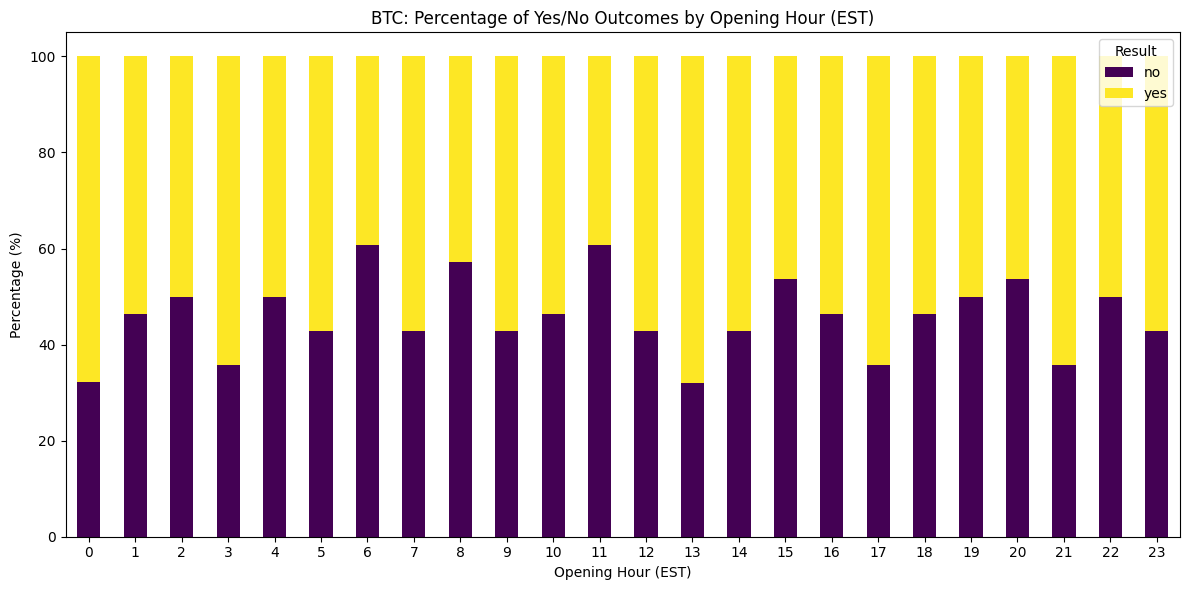

In [ ]:
# @title #- {display-mode: "form"}
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Load results from the specified CSV file
df_markets = pd.read_csv('/content/silver.csv')

# Ensure open_time is in datetime format and extract the hour
df_markets['open_time'] = pd.to_datetime(df_markets['open_time'])
df_markets['open_hour'] = df_markets['open_time'].dt.hour

# Group by 'open_hour' and 'result' and calculate percentages
hourly_result_counts = df_markets.groupby(['open_hour', 'result']).size().unstack(fill_value=0)
hourly_result_percentages = hourly_result_counts.apply(lambda x: x / x.sum() * 100, axis=1)

# Plotting the hourly result percentages
fig, ax = plt.subplots(figsize=(12, 6))
hourly_result_percentages.plot(kind='bar', stacked=True, ax=ax, cmap='viridis')

ax.set_title('BTC: Percentage of Yes/No Outcomes by Opening Hour (EST)')
ax.set_xlabel('Opening Hour (EST)')
ax.set_ylabel('Percentage (%)')
ax.set_xticks(range(len(hourly_result_percentages.index)))
ax.set_xticklabels(hourly_result_percentages.index, rotation=0)
ax.legend(title='Result')
plt.tight_layout()
plt.show()

In [ ]:
# @title 📊 Kalshi BTC Market Insights Dashboard {display-mode: "form"}

import pandas as pd
import json
from IPython.display import HTML
from google.colab import output

# --- Backend Data Processing ---
def _report_js_error(message):
    print(f"JavaScript Error: {message}")

output.register_callback('report_js_error', _report_js_error)

# Load results from the specified CSV file (ETH)
df_markets = pd.read_csv('/content/silver.csv')

# Prepare data for JS
dashboard_df = df_markets.copy()
dashboard_df['open_time'] = pd.to_datetime(dashboard_df['open_time'])
dashboard_df['open_time_str'] = dashboard_df['open_time'].dt.strftime('%Y-%m-%d %H:%M')

# Calculate KPIs
total_markets = len(dashboard_df)
yes_count = len(dashboard_df[dashboard_df['result'].str.lower() == 'yes'])
yes_rate = (yes_count / total_markets * 100) if total_markets > 0 else 0
avg_expiration = pd.to_numeric(dashboard_df['expiration_value'], errors='coerce').mean()

kpi_data = {
    "total": total_markets,
    "yes_rate": f"{yes_rate:.1f}%",
    "avg_exp": f"${avg_expiration:,.2f}"
}

json_data = dashboard_df.to_json(orient='records')

# --- Dashboard Template ---
html_template = """
<!DOCTYPE html>
<html lang="en">
<head>
    <meta charset="UTF-8">
    <link href="https://fonts.googleapis.com/css2?family=Inter:wght@400;600;700&display=swap" rel="stylesheet">
    <script src="https://cdn.jsdelivr.net/npm/chart.js"></script>
    <style>
        :root {
            --bg-color: #f4f6f8;
            --card-bg: #ffffff;
            --primary: #2563eb;
            --text-main: #1e293b;
            --text-muted: #64748b;
            --shadow: 0 4px 6px -1px rgb(0 0 0 / 0.1), 0 2px 4px -2px rgb(0 0 0 / 0.1);
        }
        body {
            font-family: 'Inter', sans-serif;
            background-color: var(--bg-color);
            color: var(--text-main);
            margin: 0;
            padding: 20px;
        }
        .dashboard-container {
            max-width: 1200px;
            margin: 0 auto;
            display: flex;
            flex-direction: column;
            gap: 24px;
        }
        .kpi-row {
            display: grid;
            grid-template-columns: repeat(auto-fit, minmax(240px, 1fr));
            gap: 20px;
        }
        .card {
            background: var(--card-bg);
            padding: 24px;
            border-radius: 12px;
            box-shadow: var(--shadow);
        }
        .kpi-card {
            text-align: center;
        }
        .kpi-value {
            font-size: 2rem;
            font-weight: 700;
            color: var(--primary);
            margin: 8px 0;
        }
        .kpi-label {
            color: var(--text-muted);
            font-size: 0.875rem;
            text-transform: uppercase;
            letter-spacing: 0.05em;
        }
        .charts-row {
            display: grid;
            grid-template-columns: 2fr 1fr;
            gap: 20px;
        }
        .canvas-wrapper {
            position: relative;
            flex-grow: 1;
            min-height: 300px;
        }
        .table-container {
            overflow-x: auto;
            background: white;
            border-radius: 12px;
            box-shadow: var(--shadow);
        }
        table {
            width: 100%;
            border-collapse: collapse;
            font-size: 0.875rem;
        }
        th {
            background: #f8fafc;
            text-align: left;
            padding: 12px 16px;
            color: var(--text-muted);
            font-weight: 600;
            border-bottom: 1px solid #e2e8f0;
        }
        td {
            padding: 12px 16px;
            border-bottom: 1px solid #f1f5f9;
        }
        .badge {
            padding: 4px 8px;
            border-radius: 4px;
            font-weight: 600;
            font-size: 0.75rem;
            text-transform: uppercase;
        }
        .badge-yes { background: #dcfce7; color: #166534; }
        .badge-no { background: #fee2e2; color: #991b1b; }
        @media (max-width: 768px) {
            .charts-row { grid-template-columns: 1fr; }
        }
    </style>
</head>
<body>
    <div class="dashboard-container">
        <h2 style="margin:0;">ETH Market Analysis Dashboard</h2>
        <div class="kpi-row">
            <div class="card kpi-card">
                <div class="kpi-label">Total Markets</div>
                <div class="kpi-value" id="kpi-total">0</div>
            </div>
            <div class="card kpi-card">
                <div class="kpi-label">YES Outcome Rate</div>
                <div class="kpi-value" id="kpi-rate">0%</div>
            </div>
            <div class="card kpi-card">
                <div class="kpi-label">Avg Expiration ($)</div>
                <div class="kpi-value" id="kpi-exp">$0</div>
            </div>
        </div>

        <div class="charts-row">
            <div class="card" style="display:flex; flex-direction:column;">
                <h3 style="margin-top:0;">Market Expiration Values</h3>
                <div class="canvas-wrapper">
                    <canvas id="mainLineChart"></canvas>
                </div>
            </div>
            <div class="card" style="display:flex; flex-direction:column;">
                <h3 style="margin-top:0;">Outcome Split</h3>
                <div class="canvas-wrapper">
                    <canvas id="outcomeDonutChart"></canvas>
                </div>
            </div>
        </div>

        <div class="table-container">
            <table id="marketTable">
                <thead>
                    <tr>
                        <th>Ticker</th>
                        <th>Open Time (EST)</th>
                        <th>Strike</th>
                        <th>Exp Value</th>
                        <th>Result</th>
                    </tr>
                </thead>
                <tbody id="tableBody"></tbody>
            </table>
        </div>
    </div>

    <script>
        window.onerror = function(message) {
            google.colab.kernel.invokeFunction('report_js_error', [message], {});
        };

        const data = DATA_PLACEHOLDER;
        const kpis = KPI_PLACEHOLDER;

        function initDashboard() {
            document.getElementById('kpi-total').innerText = kpis.total;
            document.getElementById('kpi-rate').innerText = kpis.yes_rate;
            document.getElementById('kpi-exp').innerText = kpis.avg_exp;

            const sortedData = [...data].sort((a, b) => a.open_time - b.open_time);

            new Chart(document.getElementById('mainLineChart'), {
                type: 'line',
                data: {
                    labels: sortedData.map(d => d.open_time_str),
                    datasets: [{
                        label: 'Expiration Value',
                        data: sortedData.map(d => d.expiration_value),
                        borderColor: '#2563eb',
                        backgroundColor: 'rgba(37, 99, 235, 0.1)',
                        fill: true,
                        tension: 0.3,
                        pointRadius: 2
                    }]
                },
                options: {
                    responsive: true,
                    maintainAspectRatio: false,
                    plugins: { legend: { display: false } },
                    scales: {
                        x: { display: false },
                        y: { beginAtZero: false }
                    }
                }
            });

            const outcomes = data.reduce((acc, curr) => {
                const r = curr.result.toLowerCase();
                acc[r] = (acc[r] || 0) + 1;
                return acc;
            }, {});

            new Chart(document.getElementById('outcomeDonutChart'), {
                type: 'doughnut',
                data: {
                    labels: ['Yes', 'No'],
                    datasets: [{
                        data: [outcomes.yes || 0, outcomes.no || 0],
                        backgroundColor: ['#22c55e', '#ef4444']
                    }]
                },
                options: {
                    responsive: true,
                    maintainAspectRatio: false,
                    plugins: { legend: { position: 'bottom' } }
                }
            });

            const tableBody = document.getElementById('tableBody');
            data.slice(0, 50).forEach(row => {
                const tr = document.createElement('tr');
                tr.innerHTML = `
                    <td>${row.event_ticker}</td>
                    <td>${row.open_time_str}</td>
                    <td>${row.floor_strike}</td>
                    <td>${row.expiration_value}</td>
                    <td><span class="badge badge-${row.result.toLowerCase()}">${row.result}</span></td>
                `;
                tableBody.appendChild(tr);
            });
        }

        initDashboard();
    </script>
</body>
</html>
"""

# Inject data into template
final_html = html_template.replace('DATA_PLACEHOLDER', json_data)
final_html = final_html.replace('KPI_PLACEHOLDER', json.dumps(kpi_data))

display(HTML(final_html))

In [ ]:
# @title 📊 Kalshi ETH Market Insights Dashboard {display-mode: "form"}
series = "KXDOGE15M" # @param {"type":"string","placeholder":"Series Name"}
csv = "/content/Kalshi_API_Test/KXETH15M.csv" # @param {"type":"string","placeholder":"CSV File"}
import pandas as pd
import json
from IPython.display import HTML
from google.colab import output

# --- Backend Data Processing ---
def _report_js_error(message):
    print(f"JavaScript Error: {message}")

output.register_callback('report_js_error', _report_js_error)

# Load results from the specified CSV file (ETH)
df_markets = pd.read_csv(csv)

# Prepare data for JS
dashboard_df = df_markets.copy()
dashboard_df['open_time'] = pd.to_datetime(dashboard_df['open_time'])
dashboard_df['open_time_str'] = dashboard_df['open_time'].dt.strftime('%Y-%m-%d %H:%M')

# Calculate KPIs
total_markets = len(dashboard_df)
yes_count = len(dashboard_df[dashboard_df['result'].str.lower() == 'yes'])
yes_rate = (yes_count / total_markets * 100) if total_markets > 0 else 0
avg_expiration = pd.to_numeric(dashboard_df['expiration_value'], errors='coerce').mean()

kpi_data = {
    "total": total_markets,
    "yes_rate": f"{yes_rate:.1f}%",
    "avg_exp": f"${avg_expiration:,.2f}"
}

json_data = dashboard_df.to_json(orient='records')

# --- Dashboard Template ---
html_template = """
<!DOCTYPE html>
<html lang="en">
<head>
    <meta charset="UTF-8">
    <link href="https://fonts.googleapis.com/css2?family=Inter:wght@400;600;700&display=swap" rel="stylesheet">
    <script src="https://cdn.jsdelivr.net/npm/chart.js"></script>
    <style>
        :root {
            --bg-color: #f4f6f8;
            --card-bg: #ffffff;
            --primary: #2563eb;
            --text-main: #1e293b;
            --text-muted: #64748b;
            --shadow: 0 4px 6px -1px rgb(0 0 0 / 0.1), 0 2px 4px -2px rgb(0 0 0 / 0.1);
        }
        body {
            font-family: 'Inter', sans-serif;
            background-color: var(--bg-color);
            color: var(--text-main);
            margin: 0;
            padding: 20px;
        }
        .dashboard-container {
            max-width: 1200px;
            margin: 0 auto;
            display: flex;
            flex-direction: column;
            gap: 24px;
        }
        .kpi-row {
            display: grid;
            grid-template-columns: repeat(auto-fit, minmax(240px, 1fr));
            gap: 20px;
        }
        .card {
            background: var(--card-bg);
            padding: 24px;
            border-radius: 12px;
            box-shadow: var(--shadow);
        }
        .kpi-card {
            text-align: center;
        }
        .kpi-value {
            font-size: 2rem;
            font-weight: 700;
            color: var(--primary);
            margin: 8px 0;
        }
        .kpi-label {
            color: var(--text-muted);
            font-size: 0.875rem;
            text-transform: uppercase;
            letter-spacing: 0.05em;
        }
        .charts-row {
            display: grid;
            grid-template-columns: 2fr 1fr;
            gap: 20px;
        }
        .canvas-wrapper {
            position: relative;
            flex-grow: 1;
            min-height: 300px;
        }
        .table-container {
            overflow-x: auto;
            background: white;
            border-radius: 12px;
            box-shadow: var(--shadow);
        }
        table {
            width: 100%;
            border-collapse: collapse;
            font-size: 0.875rem;
        }
        th {
            background: #f8fafc;
            text-align: left;
            padding: 12px 16px;
            color: var(--text-muted);
            font-weight: 600;
            border-bottom: 1px solid #e2e8f0;
        }
        td {
            padding: 12px 16px;
            border-bottom: 1px solid #f1f5f9;
        }
        .badge {
            padding: 4px 8px;
            border-radius: 4px;
            font-weight: 600;
            font-size: 0.75rem;
            text-transform: uppercase;
        }
        .badge-yes { background: #dcfce7; color: #166534; }
        .badge-no { background: #fee2e2; color: #991b1b; }
        @media (max-width: 768px) {
            .charts-row { grid-template-columns: 1fr; }
        }
    </style>
</head>
<body>
    <div class="dashboard-container">
        <h2 style="margin:0;">ETH Market Analysis Dashboard</h2>
        <div class="kpi-row">
            <div class="card kpi-card">
                <div class="kpi-label">Total Markets</div>
                <div class="kpi-value" id="kpi-total">0</div>
            </div>
            <div class="card kpi-card">
                <div class="kpi-label">YES Outcome Rate</div>
                <div class="kpi-value" id="kpi-rate">0%</div>
            </div>
            <div class="card kpi-card">
                <div class="kpi-label">Avg Expiration ($)</div>
                <div class="kpi-value" id="kpi-exp">$0</div>
            </div>
        </div>

        <div class="charts-row">
            <div class="card" style="display:flex; flex-direction:column;">
                <h3 style="margin-top:0;">Market Expiration Values</h3>
                <div class="canvas-wrapper">
                    <canvas id="mainLineChart"></canvas>
                </div>
            </div>
            <div class="card" style="display:flex; flex-direction:column;">
                <h3 style="margin-top:0;">Outcome Split</h3>
                <div class="canvas-wrapper">
                    <canvas id="outcomeDonutChart"></canvas>
                </div>
            </div>
        </div>

        <div class="table-container">
            <table id="marketTable">
                <thead>
                    <tr>
                        <th>Ticker</th>
                        <th>Open Time (EST)</th>
                        <th>Strike</th>
                        <th>Exp Value</th>
                        <th>Result</th>
                    </tr>
                </thead>
                <tbody id="tableBody"></tbody>
            </table>
        </div>
    </div>

    <script>
        window.onerror = function(message) {
            google.colab.kernel.invokeFunction('report_js_error', [message], {});
        };

        const data = DATA_PLACEHOLDER;
        const kpis = KPI_PLACEHOLDER;

        function initDashboard() {
            document.getElementById('kpi-total').innerText = kpis.total;
            document.getElementById('kpi-rate').innerText = kpis.yes_rate;
            document.getElementById('kpi-exp').innerText = kpis.avg_exp;

            const sortedData = [...data].sort((a, b) => a.open_time - b.open_time);

            new Chart(document.getElementById('mainLineChart'), {
                type: 'line',
                data: {
                    labels: sortedData.map(d => d.open_time_str),
                    datasets: [{
                        label: 'Expiration Value',
                        data: sortedData.map(d => d.expiration_value),
                        borderColor: '#2563eb',
                        backgroundColor: 'rgba(37, 99, 235, 0.1)',
                        fill: true,
                        tension: 0.3,
                        pointRadius: 2
                    }]
                },
                options: {
                    responsive: true,
                    maintainAspectRatio: false,
                    plugins: { legend: { display: false } },
                    scales: {
                        x: { display: false },
                        y: { beginAtZero: false }
                    }
                }
            });

            const outcomes = data.reduce((acc, curr) => {
                const r = curr.result.toLowerCase();
                acc[r] = (acc[r] || 0) + 1;
                return acc;
            }, {});

            new Chart(document.getElementById('outcomeDonutChart'), {
                type: 'doughnut',
                data: {
                    labels: ['Yes', 'No'],
                    datasets: [{
                        data: [outcomes.yes || 0, outcomes.no || 0],
                        backgroundColor: ['#22c55e', '#ef4444']
                    }]
                },
                options: {
                    responsive: true,
                    maintainAspectRatio: false,
                    plugins: { legend: { position: 'bottom' } }
                }
            });

            const tableBody = document.getElementById('tableBody');
            data.slice(0, 50).forEach(row => {
                const tr = document.createElement('tr');
                tr.innerHTML = `
                    <td>${row.event_ticker}</td>
                    <td>${row.open_time_str}</td>
                    <td>${row.floor_strike}</td>
                    <td>${row.expiration_value}</td>
                    <td><span class="badge badge-${row.result.toLowerCase()}">${row.result}</span></td>
                `;
                tableBody.appendChild(tr);
            });
        }

        initDashboard();
    </script>
</body>
</html>
"""

# Inject data into template
final_html = html_template.replace('DATA_PLACEHOLDER', json_data)
final_html = final_html.replace('KPI_PLACEHOLDER', json.dumps(kpi_data))

display(HTML(final_html))

Ticker,Open Time (EST),Strike,Exp Value,Result


In [ ]:
import os
import glob

print("--- Files in /content ---")
for f in glob.glob('/content/*.csv'):
    print(f)

print("\n--- Files in /content/Kalshi_API_Test ---")
if os.path.exists('/content/Kalshi_API_Test'):
    for f in glob.glob('/content/Kalshi_API_Test/*.csv'):
        print(f)
else:
    print("Folder /content/Kalshi_API_Test does not exist.")

--- Files in /content ---
/content/KXBNB15M.csv
/content/KXHYPE15M.csv
/content/KXXRP15M.csv
/content/KXETH15M.csv
/content/KXDOGE15M.csv
/content/KXBTC15M.csv
/content/new1.csv

--- Files in /content/Kalshi_API_Test ---
/content/Kalshi_API_Test/KXBNB15M.csv
/content/Kalshi_API_Test/KXHYPE15M.csv
/content/Kalshi_API_Test/KXXRP15M.csv
/content/Kalshi_API_Test/KXETH15M.csv
/content/Kalshi_API_Test/KXDOGE15M.csv
/content/Kalshi_API_Test/KXBTC15M.csv
/content/Kalshi_API_Test/new1.csv


In [ ]:
# @title 📊 Kalshi SOL Market Insights Dashboard {display-mode: "form"}

import pandas as pd
import json
from IPython.display import HTML
from google.colab import output

# --- Backend Data Processing ---
def _report_js_error(message):
    print(f"JavaScript Error: {message}")

output.register_callback('report_js_error', _report_js_error)

# Load results from the specified CSV file (SOL)
df_markets = pd.read_csv('/content/SOL.csv')

# Prepare data for JS
dashboard_df = df_markets.copy()
dashboard_df['open_time'] = pd.to_datetime(dashboard_df['open_time'])
dashboard_df['open_time_str'] = dashboard_df['open_time'].dt.strftime('%Y-%m-%d %H:%M')

# Calculate KPIs
total_markets = len(dashboard_df)
yes_count = len(dashboard_df[dashboard_df['result'].str.lower() == 'yes'])
yes_rate = (yes_count / total_markets * 100) if total_markets > 0 else 0
avg_expiration = pd.to_numeric(dashboard_df['expiration_value'], errors='coerce').mean()

kpi_data = {
    "total": total_markets,
    "yes_rate": f"{yes_rate:.1f}%",
    "avg_exp": f"${avg_expiration:,.2f}"
}

json_data = dashboard_df.to_json(orient='records')

# --- Dashboard Template ---
html_template = """
<!DOCTYPE html>
<html lang="en">
<head>
    <meta charset="UTF-8">
    <link href="https://fonts.googleapis.com/css2?family=Inter:wght@400;600;700&display=swap" rel="stylesheet">
    <script src="https://cdn.jsdelivr.net/npm/chart.js"></script>
    <style>
        :root {
            --bg-color: #f4f6f8;
            --card-bg: #ffffff;
            --primary: #2563eb;
            --text-main: #1e293b;
            --text-muted: #64748b;
            --shadow: 0 4px 6px -1px rgb(0 0 0 / 0.1), 0 2px 4px -2px rgb(0 0 0 / 0.1);
        }
        body {
            font-family: 'Inter', sans-serif;
            background-color: var(--bg-color);
            color: var(--text-main);
            margin: 0;
            padding: 20px;
        }
        .dashboard-container {
            max-width: 1200px;
            margin: 0 auto;
            display: flex; flex-direction: column; gap: 24px;
        }
        .kpi-row {
            display: grid; grid-template-columns: repeat(auto-fit, minmax(240px, 1fr)); gap: 20px;
        }
        .card {
            background: var(--card-bg); padding: 24px; border-radius: 12px; box-shadow: var(--shadow);
        }
        .kpi-card { text-align: center; }
        .kpi-value { font-size: 2rem; font-weight: 700; color: var(--primary); margin: 8px 0; }
        .kpi-label { color: var(--text-muted); font-size: 0.875rem; text-transform: uppercase; letter-spacing: 0.05em; }
        .charts-row {
            display: grid; grid-template-columns: 2fr 1fr; gap: 20px;
        }
        .canvas-wrapper {
            position: relative; flex-grow: 1; min-height: 300px;
        }
        .table-container {
            overflow-x: auto; background: white; border-radius: 12px; box-shadow: var(--shadow);
        }
        table {
            width: 100%; border-collapse: collapse; font-size: 0.875rem;
        }
        th {
            background: #f8fafc; text-align: left; padding: 12px 16px; color: var(--text-muted); font-weight: 600; border-bottom: 1px solid #e2e8f0;
        }
        td { padding: 12px 16px; border-bottom: 1px solid #f1f5f9; }
        .badge { padding: 4px 8px; border-radius: 4px; font-weight: 600; font-size: 0.75rem; text-transform: uppercase; }
        .badge-yes { background: #dcfce7; color: #166534; }
        .badge-no { background: #fee2e2; color: #991b1b; }
        @media (max-width: 768px) {
            .charts-row { grid-template-columns: 1fr; }
        }
    </style>
</head>
<body>
    <div class="dashboard-container">
        <h2 style="margin:0;">SOL Market Analysis Dashboard</h2>
        <div class="kpi-row">
            <div class="card kpi-card">
                <div class="kpi-label">Total Markets</div>
                <div class="kpi-value" id="kpi-total">0</div>
            </div>
            <div class="card kpi-card">
                <div class="kpi-label">YES Outcome Rate</div>
                <div class="kpi-value" id="kpi-rate">0%</div>
            </div>
            <div class="card kpi-card">
                <div class="kpi-label">Avg Expiration ($)</div>
                <div class="kpi-value" id="kpi-exp">$0</div>
            </div>
        </div>

        <div class="charts-row">
            <div class="card" style="display:flex; flex-direction:column;">
                <h3 style="margin-top:0;">SOL Expiration Values</h3>
                <div class="canvas-wrapper">
                    <canvas id="mainLineChart"></canvas>
                </div>
            </div>
            <div class="card" style="display:flex; flex-direction:column;">
                <h3 style="margin-top:0;">Outcome Split</h3>
                <div class="canvas-wrapper">
                    <canvas id="outcomeDonutChart"></canvas>
                </div>
            </div>
        </div>

        <div class="table-container">
            <table>
                <thead>
                    <tr>
                        <th>Ticker</th>
                        <th>Open Time (EST)</th>
                        <th>Strike</th>
                        <th>Exp Value</th>
                        <th>Result</th>
                    </tr>
                </thead>
                <tbody id="tableBody"></tbody>
            </table>
        </div>
    </div>

    <script>
        window.onerror = function(message) {
            google.colab.kernel.invokeFunction('report_js_error', [message], {});
        };

        const data = DATA_PLACEHOLDER;
        const kpis = KPI_PLACEHOLDER;

        function initDashboard() {
            document.getElementById('kpi-total').innerText = kpis.total;
            document.getElementById('kpi-rate').innerText = kpis.yes_rate;
            document.getElementById('kpi-exp').innerText = kpis.avg_exp;

            const sortedData = [...data].sort((a, b) => a.open_time - b.open_time);

            new Chart(document.getElementById('mainLineChart'), {
                type: 'line',
                data: {
                    labels: sortedData.map(d => d.open_time_str),
                    datasets: [{
                        label: 'SOL Expiration',
                        data: sortedData.map(d => d.expiration_value),
                        borderColor: '#8b5cf6',
                        backgroundColor: 'rgba(139, 92, 246, 0.1)',
                        fill: true,
                        tension: 0.3,
                        pointRadius: 1
                    }]
                },
                options: {
                    responsive: true,
                    maintainAspectRatio: false,
                    plugins: { legend: { display: false } },
                    scales: {
                        x: { display: false },
                        y: { beginAtZero: false }
                    }
                }
            });

            const outcomes = data.reduce((acc, curr) => {
                const r = curr.result.toLowerCase();
                acc[r] = (acc[r] || 0) + 1;
                return acc;
            }, {});

            new Chart(document.getElementById('outcomeDonutChart'), {
                type: 'doughnut',
                data: {
                    labels: ['Yes', 'No'],
                    datasets: [{
                        data: [outcomes.yes || 0, outcomes.no || 0],
                        backgroundColor: ['#22c55e', '#ef4444']
                    }]
                },
                options: {
                    responsive: true,
                    maintainAspectRatio: false,
                    plugins: { legend: { position: 'bottom' } }
                }
            });

            const tableBody = document.getElementById('tableBody');
            data.slice(0, 50).forEach(row => {
                const tr = document.createElement('tr');
                tr.innerHTML = `
                    <td>${row.event_ticker}</td>
                    <td>${row.open_time_str}</td>
                    <td>${row.floor_strike}</td>
                    <td>${row.expiration_value}</td>
                    <td><span class="badge badge-${row.result.toLowerCase()}">${row.result}</span></td>
                `;
                tableBody.appendChild(tr);
            });
        }

        initDashboard();
    </script>
</body>
</html>
"""

# Inject data into template using string replacement
final_html = html_template.replace('DATA_PLACEHOLDER', json_data)
final_html = final_html.replace('KPI_PLACEHOLDER', json.dumps(kpi_data))

display(HTML(final_html))


FileNotFoundError: [Errno 2] No such file or directory: '/content/SOL.csv'

# 🚀 Automate CSV Push to GitHub
1. Go to the **Secrets** (🔑) tab on the left.
2. Add a new secret named `GITHUB_TOKEN` with your GitHub Personal Access Token.
3. Update the `REPO_PATH` and `USER_EMAIL` below.

In [ ]:
import os
import glob
import shutil
from google.colab import userdata

# --- Configuration ---
REPO_NAME = "Kalshi_API_Test"
REPO_PATH = "JohnEvans89/Kalshi_API_Test"
USER_EMAIL = "jjevans1776@gmail.com"
USER_NAME = "JohnEvans89"
BRANCH = "main"
SUB_DIR = "CSV"  # Target subdirectory for CSVs

try:
    GITHUB_TOKEN = userdata.get('colab')
except Exception:
    print("❌ Error: 'colab' secret not found!")
    GITHUB_TOKEN = None

if GITHUB_TOKEN:
    repo_url = f"https://{GITHUB_TOKEN}@github.com/{REPO_PATH}.git"
    os.chdir('/content')

    # 1. Clean local state and clone fresh
    if os.path.exists(REPO_NAME):
        shutil.rmtree(REPO_NAME)

    print(f"⌅ Downloading {REPO_NAME} from GitHub...")
    !git clone {repo_url}

    if os.path.exists(REPO_NAME):
        os.chdir(REPO_NAME)
        # 2. Setup Identity
        !git config user.email "{USER_EMAIL}"
        !git config user.name "{USER_NAME}"

        # 3. Sync with remote
        !git fetch origin {BRANCH}
        !git checkout {BRANCH} || git checkout -b {BRANCH}
        !git pull origin {BRANCH} --rebase

        # 4. Ensure the CSV subdirectory exists inside the repo
        if not os.path.exists(SUB_DIR):
            os.makedirs(SUB_DIR)
            print(f"📁 Created directory: {SUB_DIR}")

        # 5. Copy CSVs from Colab root into the CSV folder
        csv_files = glob.glob('/content/*.csv')
        for f in csv_files:
            dest_path = os.path.join(SUB_DIR, os.path.basename(f))
            shutil.copy(f, dest_path)
            print(f"➕ Including: {SUB_DIR}/{os.path.basename(f)}")

        # 6. Commit and Push
        !git add {SUB_DIR}/*.csv
        changes = !git status --porcelain
        if changes:
            !git commit -m "Autobkkmated data update to CSV folder"
            !git push origin {BRANCH}
            print(f"✅ Success! CSVs were updated in the '{SUB_DIR}' folder at {REPO_PATH}.")
        else:
            print("ℹ️ No new data to update. Repo is already in sync.")

        os.chdir('/content')
    else:
        print("❌ Failed to clone repository.")
else:
    print("❌ Secret 'colab' not found.")

Now that you are cloning your repository into the /content/Kalshi_API_Test folder to keep your code and data together, you have two options for loading files in your notebook:

Using the Repo Path (Recommended for Git Syncing): If you want to load the files that are currently inside your local GitHub folder (to ensure they match what's in your repo), use: pd.read_csv('/content/Kalshi_API_Test/SOL.csv')

Using the Default Colab Path: The scripts you've been running save the initial files to the root /content folder. You can still use: pd.read_csv('/content/SOL.csv')

Note: The automation script I provided copies the files from the root to the Kalshi_API_Test folder before pushing. So, if you want to work on the most 'current' version before it gets pushed, use the root path. If you want to work on the versions that were successfully checked into the repo, use the Kalshi_API_Test sub-path.